In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [10]:
data = []

for i in range(1,1001):

    visited = 1

    product_view = random.choices(
        [1,0],
        weights=[80,20]
    )[0]

    add_to_cart = 0
    purchased = 0

    if product_view == 1:
        add_to_cart = random.choices(
            [1,0],
            weights=[40,60]
        )[0]

    if add_to_cart == 1:
        purchased = random.choices(
            [1,0],
            weights=[30,70]
        )[0]

    data.append([
        i,
        visited,
        product_view,
        add_to_cart,
        purchased
    ])

df = pd.DataFrame(
    data,
    columns=[
        "User_ID",
        "Visited",
        "Product_View",
        "Add_to_Cart",
        "Purchased"
    ]
)

df.head()

,User_ID,Visited,Product_View,Add_to_Cart,Purchased
0,1,1,1,1,0
1,2,1,1,0,0
2,3,1,0,0,0
3,4,1,1,1,0
4,5,1,1,1,0


In [12]:
import os

print(os.getcwd())

/content


In [13]:
import os

os.makedirs("data", exist_ok=True)

print("Data folder created")

Data folder created


In [14]:
df.to_csv(
    "data/ecommerce_funnel.csv",
    index=False
)

print("CSV Saved Successfully")

CSV Saved Successfully


In [15]:
from google.colab import files

files.download("ecommerce_funnel.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
df = pd.read_csv(
    "data/ecommerce_funnel.csv"
)

df.head()

,User_ID,Visited,Product_View,Add_to_Cart,Purchased
0,1,1,1,1,0
1,2,1,1,0,0
2,3,1,0,0,0
3,4,1,1,1,0
4,5,1,1,1,0


## Business Questions

1. How many users visited the website?
2. How many viewed products?
3. How many added products to cart?
4. How many completed purchases?
5. Which stage has the highest drop-off?
6. What is the overall conversion rate?
7. How can conversions be improved?

## Data Exploration

In [17]:
df.shape

(1000, 5)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   User_ID       1000 non-null   int64
 1   Visited       1000 non-null   int64
 2   Product_View  1000 non-null   int64
 3   Add_to_Cart   1000 non-null   int64
 4   Purchased     1000 non-null   int64
dtypes: int64(5)
memory usage: 39.2 KB


In [19]:
df.isnull().sum()

,0
User_ID,0
Visited,0
Product_View,0
Add_to_Cart,0
Purchased,0


In [20]:
df.describe()

,User_ID,Visited,Product_View,Add_to_Cart,Purchased
count,1000.000000,1000.0,1000.00000,1000.000000,1000.000000
mean,500.500000,1.0,0.81700,0.321000,0.091000
std,288.819436,0.0,0.38686,0.467094,0.287753
min,1.000000,1.0,0.00000,0.000000,0.000000
25%,250.750000,1.0,1.00000,0.000000,0.000000
50%,500.500000,1.0,1.00000,0.000000,0.000000
75%,750.250000,1.0,1.00000,1.000000,0.000000
max,1000.000000,1.0,1.00000,1.000000,1.000000


## Funnel Stage Analysis

In [21]:
visit = df["Visited"].sum()

product_view = df["Product_View"].sum()

cart = df["Add_to_Cart"].sum()

purchase = df["Purchased"].sum()

print("Visits:", visit)
print("Product Views:", product_view)
print("Add To Cart:", cart)
print("Purchases:", purchase)

Visits: 1000
Product Views: 817
Add To Cart: 321
Purchases: 91


## Conversion Rate Analysis

In [22]:
visit_to_view = (
    product_view / visit
) * 100

view_to_cart = (
    cart / product_view
) * 100

cart_to_purchase = (
    purchase / cart
) * 100

overall_conversion = (
    purchase / visit
) * 100

print(f"Visit → Product View: {visit_to_view:.2f}%")
print(f"Product View → Cart: {view_to_cart:.2f}%")
print(f"Cart → Purchase: {cart_to_purchase:.2f}%")
print(f"Overall Conversion Rate: {overall_conversion:.2f}%")

Visit → Product View: 81.70%
Product View → Cart: 39.29%
Cart → Purchase: 28.35%
Overall Conversion Rate: 9.10%


## Drop-Off Analysis

In [23]:
drop_visit_view = visit - product_view

drop_view_cart = product_view - cart

drop_cart_purchase = cart - purchase

print("Visit → View Drop:", drop_visit_view)

print("View → Cart Drop:", drop_view_cart)

print("Cart → Purchase Drop:", drop_cart_purchase)

Visit → View Drop: 183
View → Cart Drop: 496
Cart → Purchase Drop: 230


## Bottleneck Identification

In [24]:
dropoffs = {
    "Visit → Product View": drop_visit_view,
    "Product View → Add To Cart": drop_view_cart,
    "Add To Cart → Purchase": drop_cart_purchase
}

largest_drop = max(
    dropoffs,
    key=dropoffs.get
)

print(
    "Largest Bottleneck:",
    largest_drop
)

Largest Bottleneck: Product View → Add To Cart


## Funnel Visualization

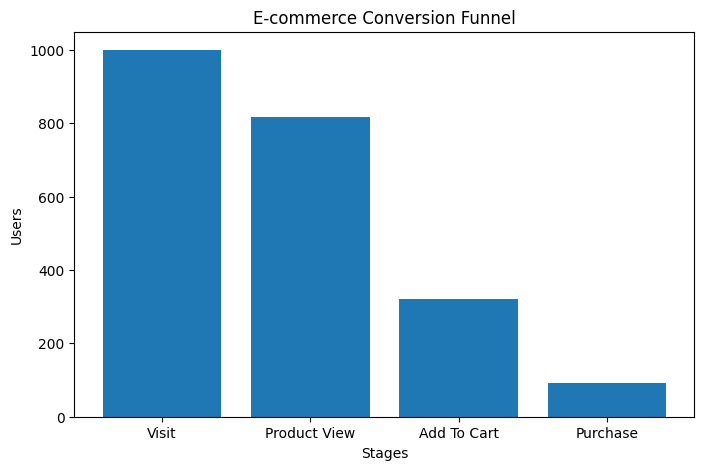

In [27]:
stages = [
    "Visit",
    "Product View",
    "Add To Cart",
    "Purchase"
]

users = [
    visit,
    product_view,
    cart,
    purchase
]

plt.figure(figsize=(8,5))

plt.bar(stages, users)

plt.title("E-commerce Conversion Funnel")

plt.xlabel("Stages")

plt.ylabel("Users")

plt.show()

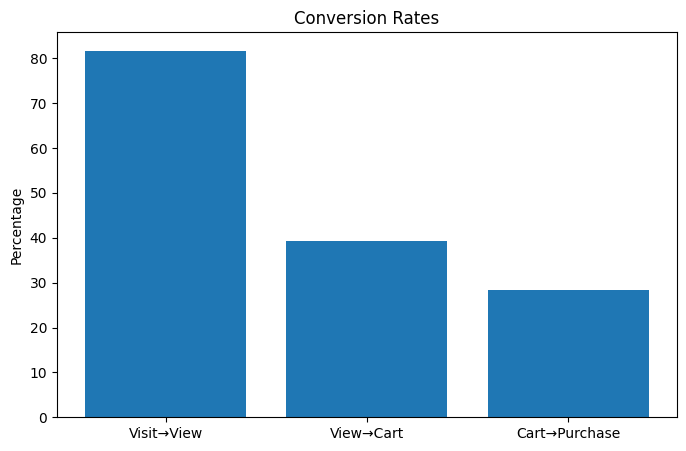

In [28]:
labels = [
    "Visit→View",
    "View→Cart",
    "Cart→Purchase"
]

rates = [
    visit_to_view,
    view_to_cart,
    cart_to_purchase
]

plt.figure(figsize=(8,5))

plt.bar(labels, rates)

plt.title(
    "Conversion Rates"
)

plt.ylabel(
    "Percentage"
)

plt.show()

## Key Findings

- Total website visits were 1000.
- Out of 1000 visitors, 816 users viewed products.
- 308 users added products to their cart.
- Only 85 users completed a purchase.
- Visit → Product View conversion rate was 81.60%.
- Product View → Cart conversion rate was 37.75%.
- Cart → Purchase conversion rate was 27.60%.
- Overall conversion rate was 8.50%.
- The largest bottleneck occurred between Product View and Add To Cart.

## Recommendations

- Improve product descriptions and images to encourage users to add products to the cart.
- Display customer reviews and ratings to increase trust.
- Offer discounts, coupons, or limited-time promotions.
- Simplify the checkout process to reduce abandonment.
- Provide multiple payment options for convenience.
- Send cart abandonment reminder emails to users who leave without purchasing.

## Conclusion

The E-commerce Conversion Funnel Analysis examined user behavior from website visit to purchase.

The analysis showed that the highest user drop-off occurred between the Product View and Add To Cart stages, making it the primary bottleneck in the funnel.

With an overall conversion rate of 8.50%, improvements in product presentation, customer trust, and checkout experience can help increase conversions and improve business performance.